# Cuaderno 5: Propiedades generales de los determinantes e interpretación geométrica

En el Cuaderno 4 aprendimos a **calcular** determinantes $2\times 2$ y $3\times 3$ por definición. En este cuaderno profundizamos en dos aspectos:

1. **Propiedades generales** de los determinantes: cómo cambian (o no cambian) ante operaciones elementales de fila, y cómo se comportan frente a la suma, el producto, la transposición y la inversión de matrices. Estas propiedades son la base de la **segunda forma** de calcular determinantes (por eliminación de Gauss), que veremos más adelante.
2. **Interpretación geométrica**: el determinante no es solo un número que sale de una fórmula, sino que mide **área** (en 2D) o **volumen** (en 3D) del paralelogramo o paralelepípedo formado por las columnas de la matriz, y su **signo** indica si la transformación asociada preserva o invierte la orientación.

Cerramos con ejercicios propuestos y preguntas conceptuales para practicar ambos temas.

In [1]:
from sympy import Matrix, eye, symbols, Rational, sqrt, acos, simplify, nsimplify
init_printing = __import__('sympy').init_printing
init_printing()  # para que las matrices se vean bonitas

## 1. Propiedades generales de los determinantes

Repasamos las propiedades más importantes, cada una con un ejemplo numérico que la verifica usando `sympy`.

### 1.1 El determinante de la identidad es 1

$$\det(I) = 1$$

para cualquier matriz identidad $I$ (de cualquier tamaño).

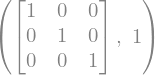

In [2]:
I = eye(3)
I, I.det()

### 1.2 Fila (o columna) de ceros $\Rightarrow$ determinante cero

Si una matriz tiene una fila o columna completamente de ceros, su determinante es $0$.

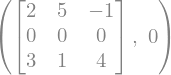

In [3]:
A = Matrix([
    [2, 5, -1],
    [0, 0, 0],
    [3, 1, 4]
])
A, A.det()

### 1.3 Filas (o columnas) iguales o proporcionales $\Rightarrow$ determinante cero

Si dos filas (o columnas) son iguales, o una es múltiplo escalar de otra, el determinante es $0$.

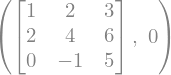

In [4]:
B = Matrix([
    [1, 2, 3],
    [2, 4, 6],   # fila 2 = 2 * fila 1
    [0, -1, 5]
])
B, B.det()

### 1.4 Intercambiar dos filas cambia el signo del determinante

Si $A'$ se obtiene de $A$ intercambiando dos filas, entonces

$$\det(A') = -\det(A)$$

In [5]:
A = Matrix([
    [2, 1, 0],
    [1, 3, 2],
    [4, 0, 1]
])
Ap = A.copy()
Ap[0, :], Ap[1, :] = Ap[1, :], Ap[0, :]  # intercambiamos filas 1 y 2
A.det(), Ap.det()

### 1.5 Multiplicar una sola fila por un escalar $k$ multiplica el determinante por $k$

Si $A'$ se obtiene de $A$ multiplicando **una** fila por $k$, entonces

$$\det(A') = k \cdot \det(A)$$

In [6]:
k = 5
Ap = A.copy()
Ap[1, :] = k * Ap[1, :]
A.det(), Ap.det(), k * A.det()

### 1.6 Sumar un múltiplo de una fila a otra no cambia el determinante

Esta es la propiedad clave detrás de la eliminación de Gauss para calcular determinantes: si $A'$ se obtiene de $A$ sumando a una fila un múltiplo de otra,

$$\det(A') = \det(A)$$

In [7]:
Ap = A.copy()
Ap[2, :] = Ap[2, :] - 3*Ap[0, :]
A.det(), Ap.det()

### 1.7 Escalar toda la matriz: $\det(cA) = c^n \det(A)$

Si multiplicamos **todas** las filas de una matriz $n\times n$ por un escalar $c$ (es decir, calculamos $cA$), el determinante se multiplica por $c^n$, porque cada una de las $n$ filas aporta un factor $c$.

In [8]:
c = 2
n = A.shape[0]
A.det(), (c*A).det(), c**n * A.det()

### 1.8 El determinante no cambia al transponer: $\det(A^T) = \det(A)$

In [9]:
A.det(), A.T.det()

### 1.9 Determinante de un producto: $\det(AB) = \det(A)\,\det(B)$

El determinante del producto de dos matrices cuadradas es el producto de sus determinantes (¡pero en general $\det(A+B) \neq \det(A)+\det(B)$!).

In [10]:
Bm = Matrix([
    [1, 0, 2],
    [3, 1, -1],
    [0, 2, 4]
])
(A*Bm).det(), A.det()*Bm.det()

Comparemos ahora con la suma, para confirmar que **no** hay una propiedad análoga:

In [11]:
(A + Bm).det(), A.det() + Bm.det()

### 1.10 Invertibilidad: $A$ es invertible $\iff$ $\det(A) \neq 0$

Cuando $\det(A) \neq 0$, la matriz es invertible y además

$$\det(A^{-1}) = \frac{1}{\det(A)}$$

Cuando $\det(A) = 0$, la matriz es **singular** (no invertible).

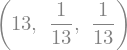

In [12]:
A.det(), A.inv().det(), 1/A.det()

In [13]:
Sing = Matrix([
    [1, 2, 3],
    [2, 4, 6],
    [0, -1, 5]
])
Sing.det()  # es 0: filas 1 y 2 son proporcionales, por 1.3 la matriz es singular

### Resumen de propiedades

| Operación / situación | Efecto en $\det(A)$ |
|---|---|
| $A = I$ | $\det(I) = 1$ |
| Fila o columna de ceros | $\det(A) = 0$ |
| Dos filas iguales o proporcionales | $\det(A) = 0$ |
| Intercambiar dos filas | cambia de signo |
| Multiplicar **una** fila por $k$ | se multiplica por $k$ |
| Sumar un múltiplo de una fila a otra | no cambia |
| Escalar toda la matriz ($cA$), $n\times n$ | se multiplica por $c^n$ |
| Transponer ($A^T$) | no cambia |
| Producto $AB$ | $\det(AB) = \det(A)\det(B)$ |
| Inversa $A^{-1}$ (si existe) | $\det(A^{-1}) = 1/\det(A)$ |
| $\det(A) \neq 0$ | $A$ es invertible |
| $\det(A) = 0$ | $A$ es singular (no invertible) |

## 2. Interpretación geométrica de los determinantes

Además de ser un número que se calcula con una fórmula, el determinante tiene un significado geométrico muy concreto:

> $|\det(A)|$ es el **factor de escala del área (en 2D) o del volumen (en 3D)** cuando aplicamos la transformación lineal $T(\mathbf{x}) = A\mathbf{x}$, y el **signo** de $\det(A)$ indica si esa transformación **preserva** ($+$) o **invierte** ($-$) la orientación del espacio.

En particular, si las columnas de $A$ son los vectores $\mathbf{v}_1, \dots, \mathbf{v}_n$, entonces $|\det(A)|$ es el área o volumen del paralelogramo/paralelepípedo que forman esos vectores.

### 2.1 Caso $2\times 2$: área del paralelogramo

Si $A = \begin{bmatrix} u_1 & v_1 \\ u_2 & v_2 \end{bmatrix}$ tiene como columnas los vectores $\mathbf{u} = (u_1, u_2)$ y $\mathbf{v} = (v_1, v_2)$, entonces

$$|\det(A)| = \text{área del paralelogramo formado por } \mathbf{u} \text{ y } \mathbf{v}$$

Verifiquémoslo comparando con la fórmula geométrica del área, $\text{área} = \|\mathbf{u}\|\,\|\mathbf{v}\|\sin(\theta)$, donde $\theta$ es el ángulo entre los vectores.

<div align = 'center'>
<img src = 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTA0cMuHcjQhOzMS3nvzK7NLOIv9BXde8_MTcFdxTvUQfZhYxYwuISRawOQ&s=10'>
</div>

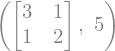

In [14]:
u = Matrix([3, 1])
v = Matrix([1, 2])
Auv = Matrix.hstack(u, v)   # u y v como columnas
Auv, Auv.det()

In [15]:
norm_u = sqrt(u.dot(u))
norm_v = sqrt(v.dot(v))
cos_theta = u.dot(v) / (norm_u * norm_v)
sin_theta = sqrt(1 - cos_theta**2)
area = norm_u * norm_v * sin_theta

simplify(area), abs(Auv.det())  # deben coincidir

### El signo del determinante indica la orientación

Si intercambiamos las columnas (es decir, el orden de los vectores $\mathbf{u}, \mathbf{v}$), el área del paralelogramo no cambia, pero el signo del determinante sí:

In [16]:
Avu = Matrix.hstack(v, u)  # ahora v primero, u después
Auv.det(), Avu.det()  # mismo valor absoluto, signo opuesto

### 2.2 Caso $3\times 3$: volumen del paralelepípedo

De la misma forma, si $A$ tiene como columnas tres vectores $\mathbf{u}, \mathbf{v}, \mathbf{w} \in \mathbb{R}^3$, entonces $|\det(A)|$ es el **volumen** del paralelepípedo que forman. Esto coincide con el llamado *producto mixto* o *triple producto escalar*:

$$|\det(A)| = |\mathbf{u} \cdot (\mathbf{v} \times \mathbf{w})|$$

<div align = 'center'>
<img src = 'https://upload.wikimedia.org/wikipedia/commons/thumb/c/c7/Paralelep%C3%ADpedo_determinado_por_tres_vectores.svg/250px-Paralelep%C3%ADpedo_determinado_por_tres_vectores.svg.png'>
</div>

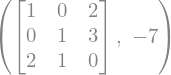

In [17]:
u = Matrix([1, 0, 2])
v = Matrix([0, 1, 1])
w = Matrix([2, 3, 0])
A3 = Matrix.hstack(u, v, w)
A3, A3.det()

In [18]:
def cross(a, b):
    return Matrix([
        a[1]*b[2] - a[2]*b[1],
        a[2]*b[0] - a[0]*b[2],
        a[0]*b[1] - a[1]*b[0]
    ])

triple_producto = u.dot(cross(v, w))
triple_producto, A3.det()  # deben coincidir

### 2.3 El determinante como factor de escala de una transformación lineal

Para cualquier región (área en 2D, volumen en 3D) que transformemos con $T(\mathbf{x}) = A\mathbf{x}$, su área/volumen queda multiplicado por $|\det(A)|$:

$$\text{área o volumen}\big(T(\text{región})\big) = |\det(A)| \cdot \text{área o volumen}(\text{región})$$

Esto explica de forma geométrica por qué $\det(A) = 0 \iff A$ es singular: si $\det(A) = 0$, la transformación **aplasta** el espacio a una dimensión menor (por ejemplo, un plano en $\mathbb{R}^3$ se convierte en una recta o un punto), y por lo tanto todo volumen se colapsa a $0$.

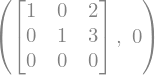

In [19]:
# Tres vectores coplanares (uno es combinacion lineal de los otros dos): el "volumen" colapsa
u = Matrix([1, 0, 0])
v = Matrix([0, 1, 0])
w = 2*u + 3*v  # w esta en el plano generado por u y v
A_colapsa = Matrix.hstack(u, v, w)
A_colapsa, A_colapsa.det()

### Resumen de la interpretación geométrica

- $2\times 2$: $|\det(A)|$ = área del paralelogramo formado por las columnas de $A$.
- $3\times 3$: $|\det(A)|$ = volumen del paralelepípedo formado por las columnas de $A$.
- El **signo** de $\det(A)$ indica si la transformación $T(\mathbf{x}) = A\mathbf{x}$ preserva ($+$) o invierte ($-$) la orientación.
- $|\det(A)|$ es el **factor de escala** del área/volumen bajo la transformación lineal asociada a $A$.
- $\det(A) = 0$ significa que la transformación colapsa el espacio a una dimensión menor (los vectores columna son linealmente dependientes), lo cual coincide con que $A$ sea singular.

## Ejercicios propuestos

### Ejercicio 1: propiedades con una matriz concreta

Dada

$$A = \begin{bmatrix} 1 & 2 & 0 \\ 3 & 1 & -1 \\ 0 & 2 & 4 \end{bmatrix}$$

verifica con `sympy`:

a) $\det(A^T) = \det(A)$.

b) Si $A'$ se obtiene intercambiando las filas 1 y 3 de $A$, entonces $\det(A') = -\det(A)$.

c) Si $A'' = 3A$, entonces $\det(A'') = 3^3 \det(A)$.

In [20]:
# Ejercicio 1
A = Matrix([[1, 2, 0], [3, 1, -1], [0, 2, 4]])


### Ejercicio 2: determinante de un producto

Dadas

$$A = \begin{bmatrix} 2 & 0 \\ 1 & 3 \end{bmatrix}, \qquad B = \begin{bmatrix} 1 & 4 \\ -2 & 1 \end{bmatrix}$$

verifica que $\det(AB) = \det(A)\det(B)$ y comprueba también que $\det(A+B) \neq \det(A) + \det(B)$.

In [21]:
# Ejercicio 2
A = Matrix([[2, 0], [1, 3]])
B = Matrix([[1, 4], [-2, 1]])


### Ejercicio 3: área de un paralelogramo

Calcula, usando el determinante, el área del paralelogramo formado por los vectores

$$\mathbf{u} = (4, 1), \qquad \mathbf{v} = (2, 3)$$

Luego verifica tu resultado con la fórmula $\|\mathbf{u}\|\|\mathbf{v}\|\sin(\theta)$.

In [22]:
# Ejercicio 3
u = Matrix([4, 1])
v = Matrix([2, 3])


### Ejercicio 4: volumen de un paralelepípedo

Calcula el volumen del paralelepípedo formado por

$$\mathbf{u} = (1, 2, 0), \qquad \mathbf{v} = (0, 1, 3), \qquad \mathbf{w} = (2, 0, 1)$$

usando el determinante, y verifica con el producto mixto $\mathbf{u}\cdot(\mathbf{v}\times\mathbf{w})$.

In [23]:
# Ejercicio 4
u = Matrix([1, 2, 0])
v = Matrix([0, 1, 3])
w = Matrix([2, 0, 1])


### Ejercicio 5: invertibilidad e interpretación geométrica

Para cada matriz, decide **sin calcular el determinante completo** (razonando sobre sus filas/columnas) si es singular o invertible. Luego verifica con `sympy` y explica qué significa el resultado en términos de área/volumen.

$$C = \begin{bmatrix} 1 & 2 & 3 \\ 0 & -1 & 4 \\ 2 & 4 & 6 \end{bmatrix}, \qquad D = \begin{bmatrix} 1 & 0 & 2 \\ 3 & 1 & -1 \\ 0 & 2 & 5 \end{bmatrix}$$

In [24]:
# Ejercicio 5
C = Matrix([[1, 2, 3], [0, -1, 4], [2, 4, 6]])
D = Matrix([[1, 0, 2], [3, 1, -1], [0, 2, 5]])


## Preguntas conceptuales

Para cada pregunta, responde primero razonando (sin calcular), y luego comprueba tu respuesta construyendo un ejemplo numérico con `sympy`. Si tu conjetura falla, ajusta el razonamiento hasta que sea consistente con los ejemplos.

### Pregunta 1: escalar una sola fila vs. escalar toda la matriz

¿Por qué $\det(cA) = c^n\det(A)$ (con $c$ multiplicando **todas** las filas) mientras que multiplicar una **sola** fila por $c$ solo multiplica el determinante por $c$ (no por $c^n$)? Relaciona tu respuesta con la interpretación geométrica de área/volumen.

In [25]:
# Pregunta 1: compara escalar una fila vs escalar toda la matriz, para n = 2 y n = 3


### Pregunta 2: vectores paralelos en 2D

Si $\mathbf{u}$ y $\mathbf{v}$ son paralelos (uno es múltiplo escalar del otro), ¿qué área forman? ¿Qué valor esperas para $\det([\mathbf{u}\ \mathbf{v}])$? Verifica con un ejemplo.

In [26]:
# Pregunta 2: elige u y v paralelos y calcula el determinante


### Pregunta 3: determinante y transformación inversa

Si $A$ es invertible y $T(\mathbf{x}) = A\mathbf{x}$ escala las áreas por un factor $|\det(A)|$, ¿por qué factor esperas que $T^{-1}$ (la transformación inversa, asociada a $A^{-1}$) escale las áreas? Verifica tu conjetura calculando $\det(A^{-1})$ para un ejemplo $2\times 2$.

In [27]:
# Pregunta 3: compara det(A) y det(A^{-1})
